# Exp1 Controlled Identifiability Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

rows = []
for name in ['README.md','requirements.txt','reproduce_fast.py','reproduce_full.py','reproduce_paper.py','code_check.py','self_check.py','output_manifest.md','docs','outputs','runlogs']:
    rows.append({'path': name, 'exists': (ROOT/name).exists()})
display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if not row['exists'] and row['path'] in {'README.md','outputs'}]
if missing:
    display(Markdown('Warning: required display/interface paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub display paths are present.'))


,path,exists
0,README.md,True
1,requirements.txt,True
2,reproduce_fast.py,True
3,reproduce_full.py,True
4,reproduce_paper.py,True
5,code_check.py,True
6,self_check.py,True
7,output_manifest.md,True
8,docs,True
9,outputs,True


Required GitHub display paths are present.

In [2]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

csvs = prefer_outputs(find_files(['outputs/**/summaries/*.csv','outputs/**/summary/*.csv','outputs/**/tables/*.csv','outputs/**/checks/*.csv','outputs/**/metadata/*.csv']))
display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)


Found `35` CSV/table/check/metadata files. Showing selected previews.

**outputs/full/checks/self_check_report.csv**

,check_name,status,details
0,backend completed,PASSED,completed
1,contextual estimand declared,PASSED,all learners observe X_t; comparator is the co...
2,primary shared-path contract declared,PASSED,pre-generated shared state/context/delay paths...
3,structural EM contract declared,PASSED,default EM integrates P(D=d|observable source ...
4,proxy feature-consistency contract declared,PASSED,"proxy action selection, labelled source update..."
5,no output marked as paper result,PASSED,paper_result=False
6,seed summary schema,PASSED,missing=[]
7,expected run count,PASSED,expected=7920; observed=7920


Rows: `27` | Columns: `3`

**outputs/full/metadata/artifacts_manifest.csv**

...

,delay_setting,regime,method,bootstrap_ci95_low,bootstrap_ci95_high,n
0,action_structural_stress,labelled,anonymous_delayed,7521.886218,7961.130683,30
1,action_structural_stress,labelled,causal_em,1702.456597,1850.670111,30
2,action_structural_stress,labelled,causal_em_misspecified,1694.462231,1882.647189,30
3,action_structural_stress,labelled,causal_labeled,1704.391820,1859.588747,30
4,action_structural_stress,labelled,delayed_exp3,7366.971052,7839.826717,30
5,action_structural_stress,labelled,delayed_ucb,4662.041023,5027.640000,30
6,action_structural_stress,labelled,naive,4411.381325,5069.779896,30
7,action_structural_stress,labelled,naive_ewma,4488.360671,5003.476194,30


Rows: `264` | Columns: `6`

**outputs/full/summaries/diagnostic_summary.csv**

,experiment_id,delay_setting,delay_family,setting_role,policy_dependent_delay,regime,method,n_seeds,mean_delay,trace_observed_mean_delay,...,source_state_mismatch_mean,source_context_mismatch_mean,proxy_state_error_mean,soft_attribution_true_mass,soft_attribution_top1_accuracy,assignment_entropy,attribution_error,effective_feedback_units,n_observed_arrivals,n_soft_assignment_events
0,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,anonymous_delayed,30,15.037525,15.000115,...,0.535402,0.652594,NaN,NaN,NaN,NaN,NaN,4643.400000,4643.400000,0.0
1,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,causal_em,30,15.380705,15.000115,...,0.538282,0.655109,NaN,NaN,NaN,NaN,NaN,4620.733333,4620.733333,0.0
2,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,causal_em_misspecified,30,14.462998,15.000115,...,0.527813,0.646019,NaN,NaN,NaN,NaN,NaN,4641.233333,4641.233333,0.0
3,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,causal_labeled,30,15.390681,15.000115,...,0.541836,0.658724,NaN,1.0,1.0,NaN,0.0,4612.466667,4612.466667,0.0
4,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,delayed_exp3,30,15.012678,15.000115,...,0.535143,0.652811,NaN,NaN,NaN,NaN,NaN,4639.266667,4639.266667,0.0
5,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,delayed_ucb,30,15.000835,15.000115,...,0.533487,0.651874,NaN,NaN,NaN,NaN,NaN,4641.000000,4641.000000,0.0
6,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,naive,30,14.720577,15.000115,...,0.527216,0.645833,NaN,NaN,NaN,NaN,NaN,4634.966667,4634.966667,0.0
7,exp1_controlled_identifiability_contextual,action_structural_stress,action_structural,policy_dependent_stress,True,labelled,naive_ewma,30,14.757393,15.000115,...,0.529621,0.649035,NaN,NaN,NaN,NaN,NaN,4634.566667,4634.566667,0.0


Rows: `264` | Columns: `23`

Found `11` PNG figure files. Showing selected embedded figures.

**outputs/full/figures/png/fig_exp1_attribution_diagnostics.png**

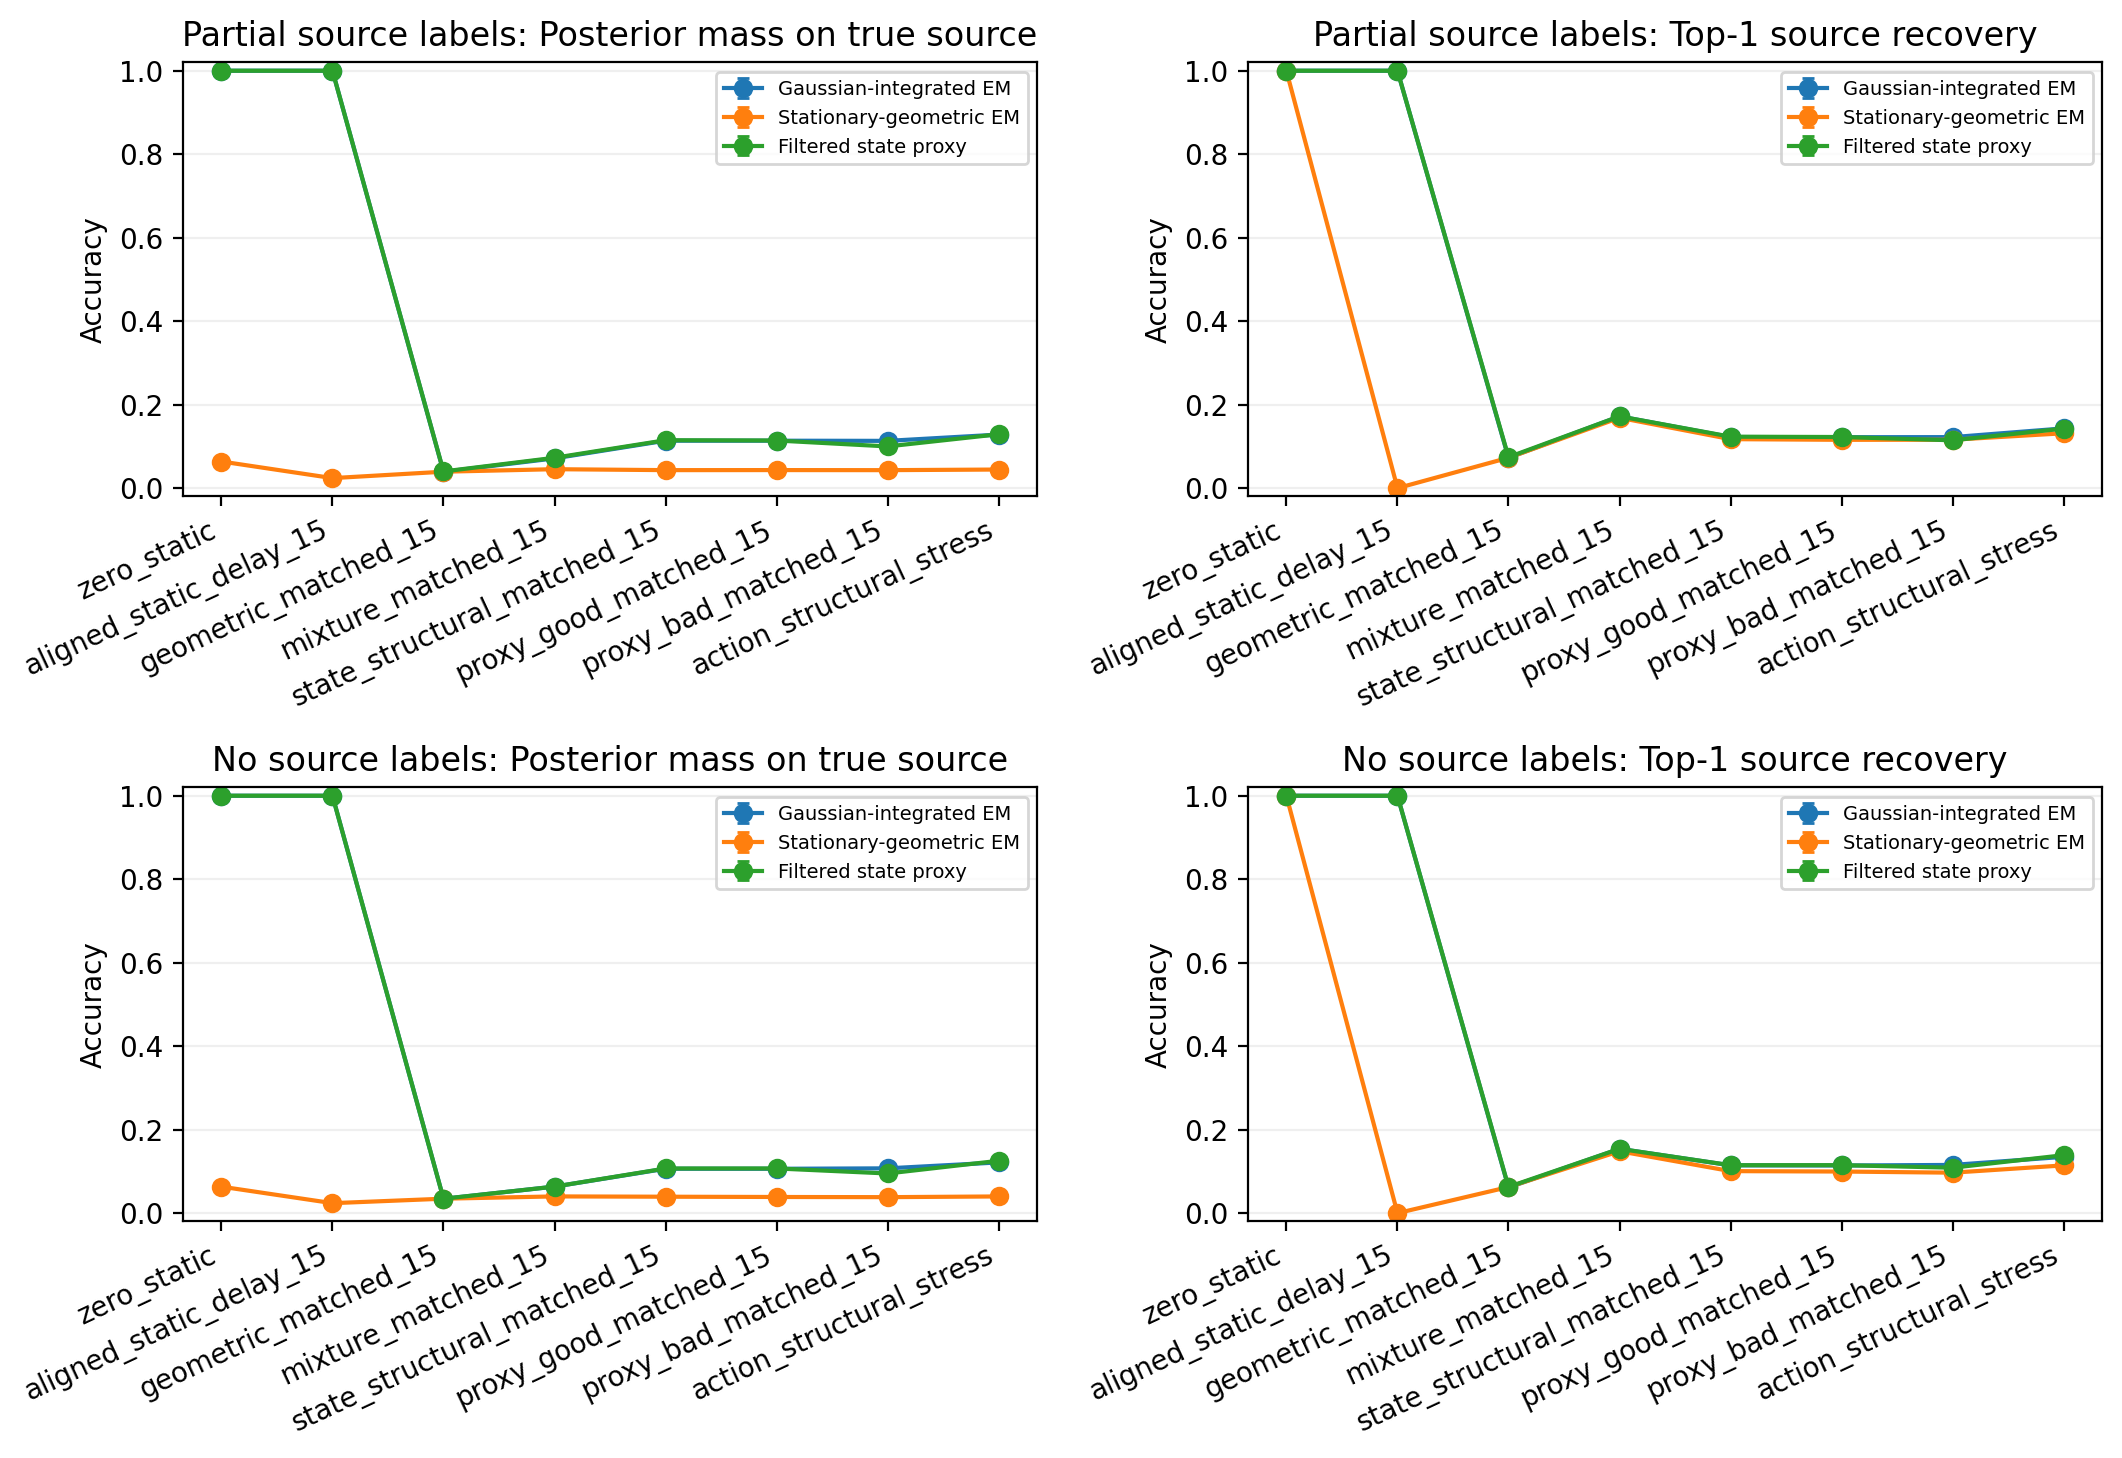

**outputs/full/figures/png/fig_exp1_proxy_quality.png**

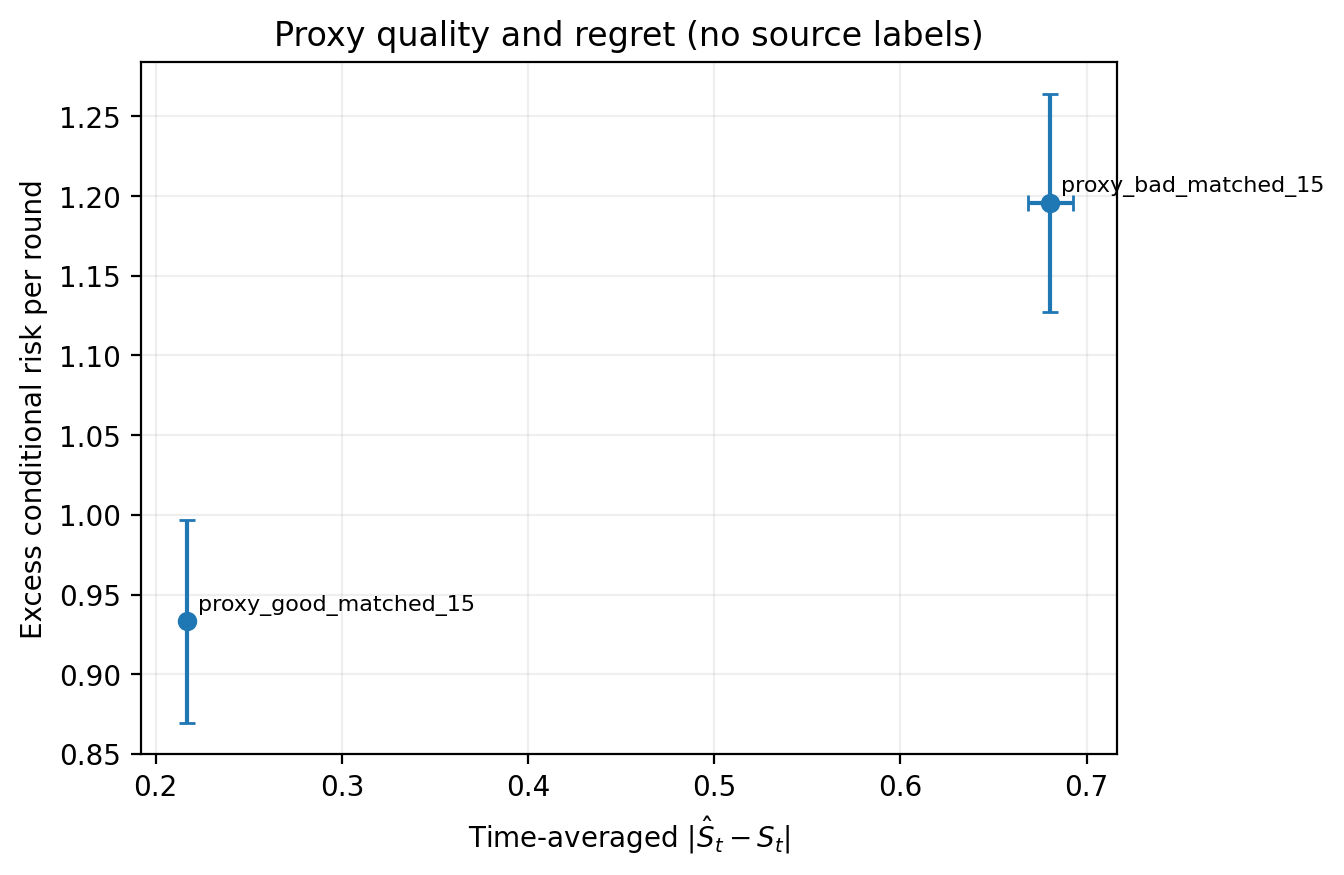

**outputs/full/figures/png/fig_exp1_same_mean_delay.png**

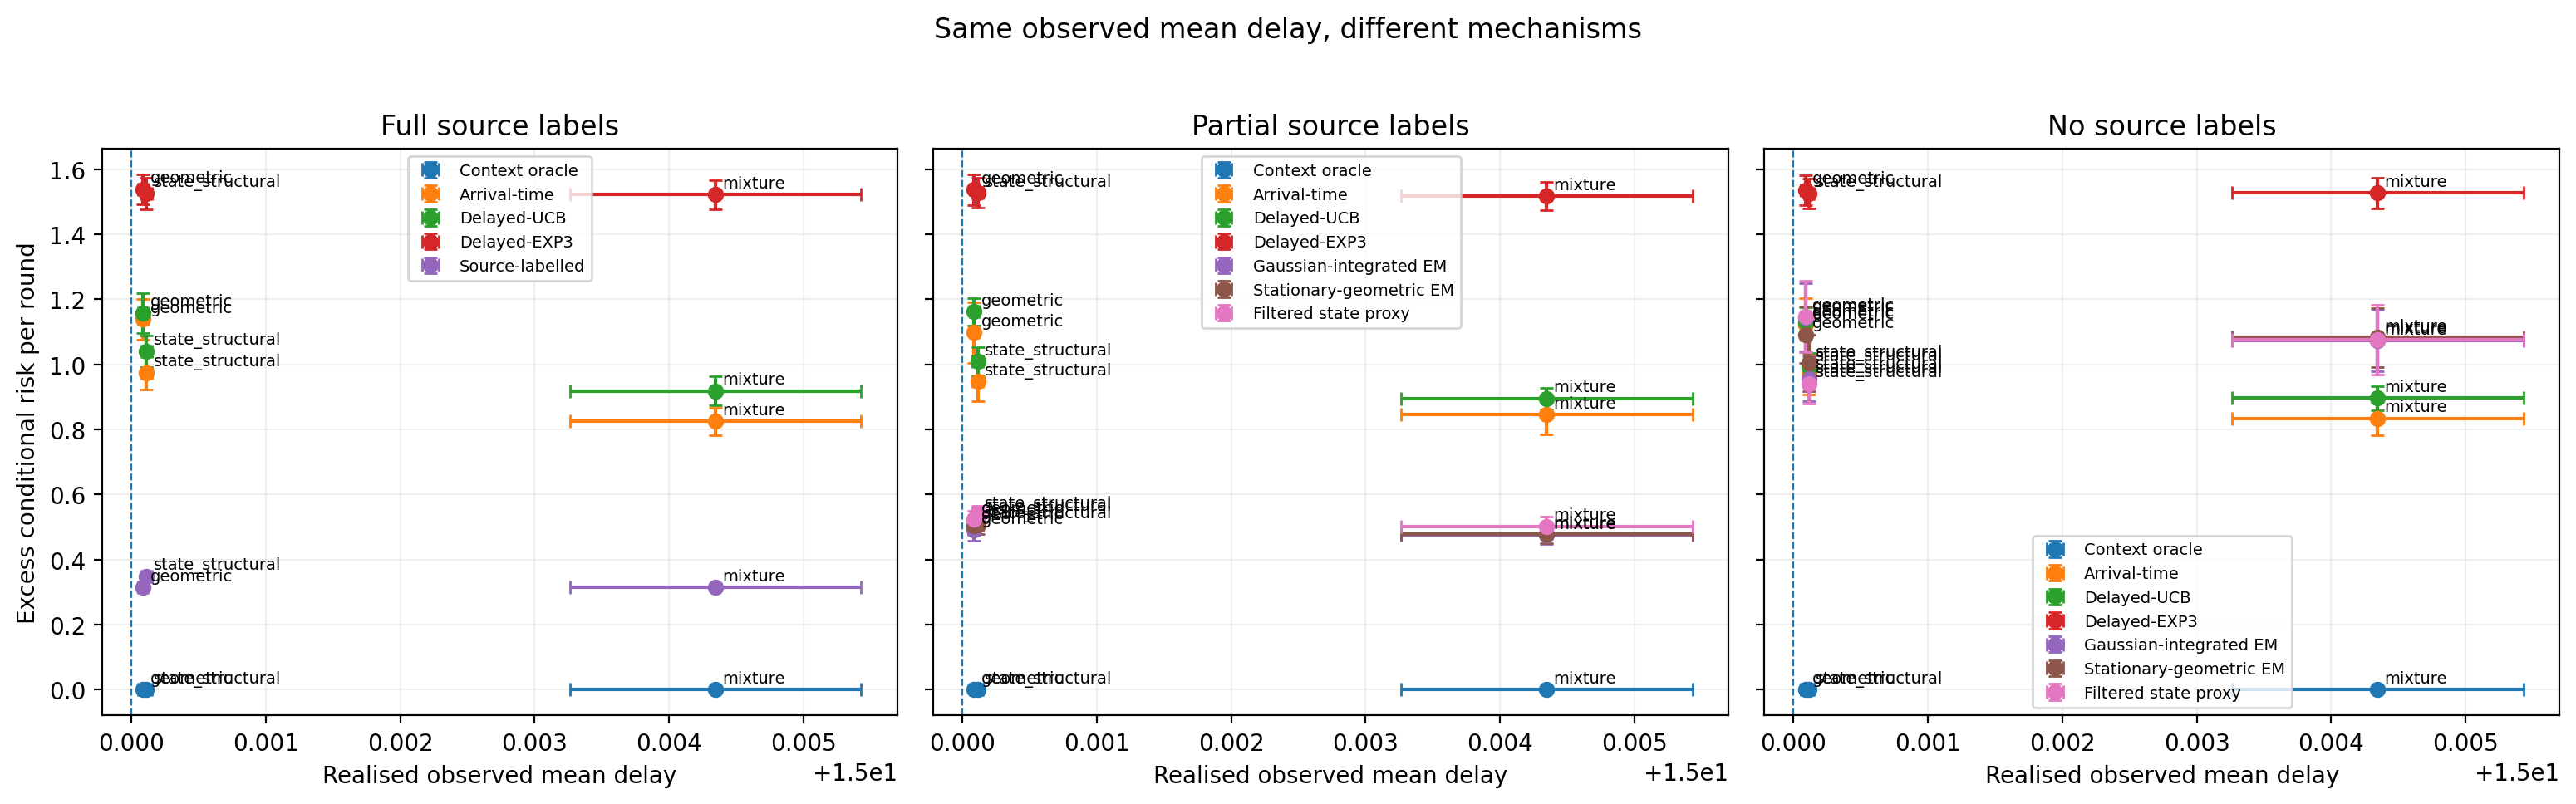

**outputs/full/figures/png/fig_exp1_validity_boundary.png**

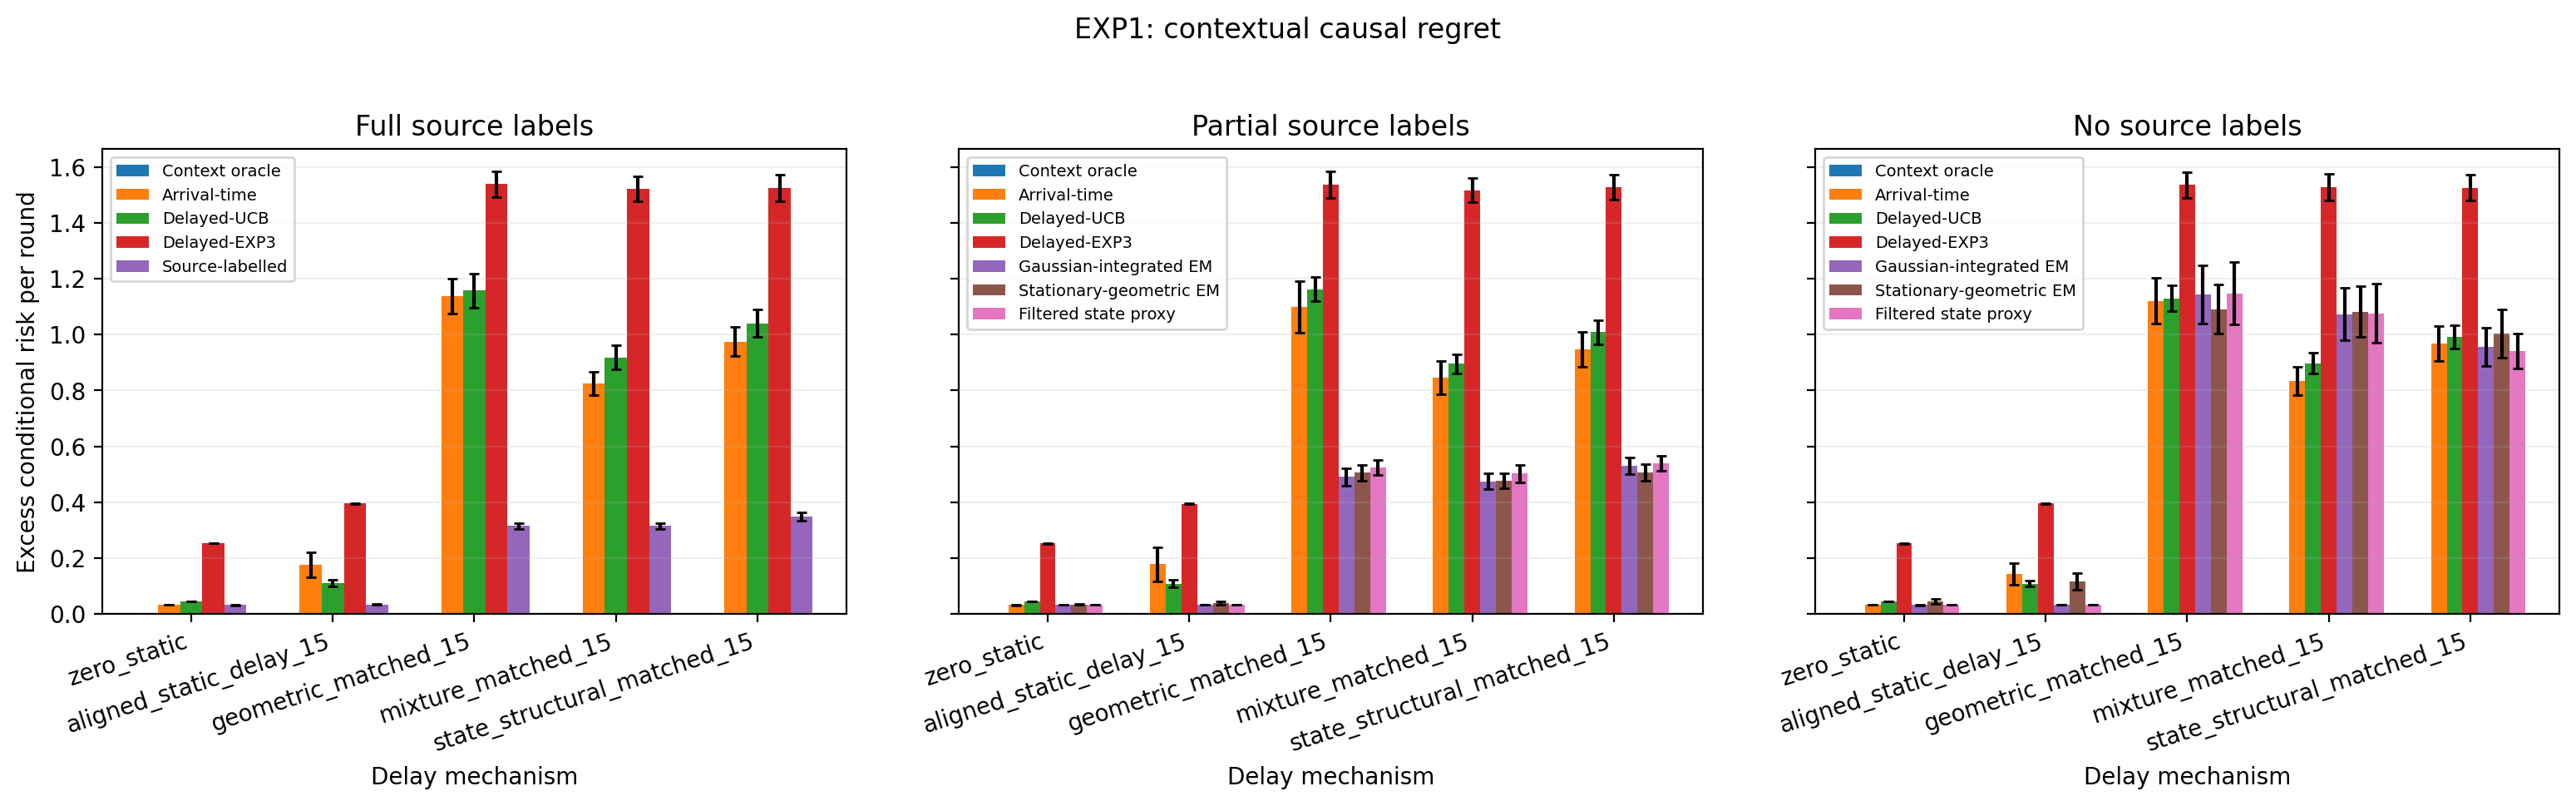

In [3]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)


In [4]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

logs = find_files(['runlogs/*','outputs/**/logs/*','*.log','outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size/1024, 1)} for p in logs[:30]]
display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))


Found `13` runlog/check records.

,path,size_kb
0,outputs/code_check_smoke/checks/self_check_rep...,2.3
1,outputs/code_check_smoke/checks/self_check_rep...,2.4
2,outputs/fast/checks/self_check_report.csv,1.9
3,outputs/fast/checks/self_check_report.md,2.0
4,outputs/full/checks/self_check_report.csv,2.3
5,outputs/full/checks/self_check_report.md,2.4
6,runlogs/exp1_code_check_cloud.log,1.8
7,runlogs/exp1_fast_cloud.log,2.3
8,runlogs/exp1_full.log,23.9
9,runlogs/exp1_full_outputs_filelist.txt,1.9


This notebook only reads existing outputs; no experiment entrypoint was executed.